In [6]:
import sys
print(sys.executable)

c:\Users\w\AppData\Local\Programs\Python\Python314\python.exe


In [7]:
!{sys.executable} -m pip install catboost

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [9]:
df = pd.read_csv(r'D:\ML-Project\notebook\StudentsPerformance.csv')

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
## preparing X and y variables
X = df.drop(columns=['math score'])

In [16]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [17]:
y= df['math score']

In [21]:
# Numerical & categorical features
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

# Imports
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Transformers
numeric_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

C:\Users\w\AppData\Local\Temp\ipykernel_18652\4262563895.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [23]:
X=preprocessor.fit_transform(X)

In [24]:
X

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]], shape=(1000, 19))

In [26]:
## seperate dataset into train and  test 

import numpy as np
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

In [27]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    
    return mae, rmse, r2_square

In [34]:
model_dict = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in model_dict.items():
    
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(name)
    model_list.append(name)
    
    print('Model performance for Training set')
    print("- RMSE: {:.4f}".format(model_train_rmse))
    print("- MAE: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- RMSE: {:.4f}".format(model_test_rmse))
    print("- MAE: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- RMSE: 5.3231
- MAE: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3940
- MAE: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- RMSE: 6.5938
- MAE: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- RMSE: 6.5197
- MAE: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- RMSE: 5.3233
- MAE: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3904
- MAE: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- RMSE: 5.7128
- MAE: 4.5168
- R2 Score: 0.8552
----------------------------------
Model performance for Test set
- RMSE: 7.2538
- MAE: 5.6190
- R2 Score: 0.7838


Decision Tree
Model performance for Training set
- RMSE: 0.2795
- MAE: 0.0187
- R2 Score: 0.9997
----------------------------------
Model performance fo

In [35]:
import pandas as pd

results_df = pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(by='R2_Score', ascending=False)

print(results_df)

                Model Name  R2_Score
2                    Ridge  0.880593
0        Linear Regression  0.880433
5  Random Forest Regressor  0.851767
7       CatBoost Regressor  0.851632
8       AdaBoost Regressor  0.847158
1                    Lasso  0.825320
6             XGBRegressor  0.821221
3    K-Neighbors Regressor  0.783770
4            Decision Tree  0.730745


In [37]:

lin_model = LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

score = r2_score(y_test, y_pred) * 100

print("R2 Score of the model is {:.2f}%".format(score))

R2 Score of the model is 88.04%


Text(0, 0.5, 'Predict')

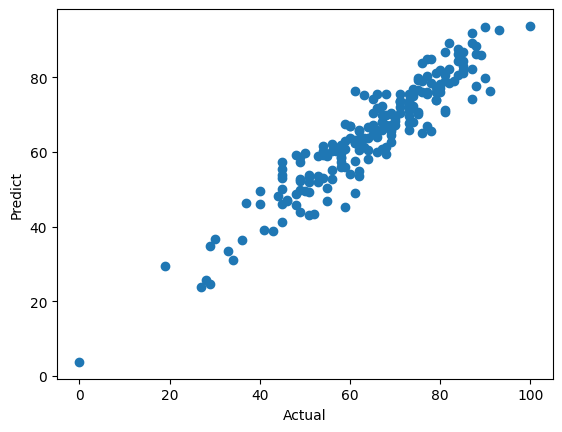

In [39]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predict')

<Axes: xlabel='math score'>

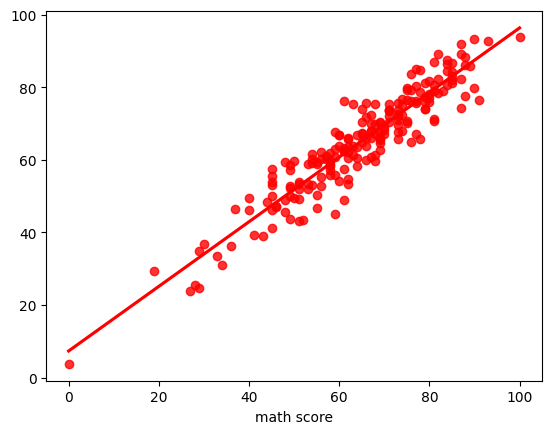

In [41]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [42]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predict Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predict Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
